In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

orders_url = "https://drive.google.com/file/d/1Tla62vfu__kCqvgypZyVt2S9VuC016yH/view?usp=sharing"
orderlines_url = "https://drive.google.com/file/d/1OhtkQS2fwOYdzfd-qPh7im35iLc-L9TA/view?usp=sharing"
products_url = "https://drive.google.com/file/d/1s7Lai4NSlsYjGEPg1QSOUJobNYVsZBOJ/view?usp=sharing"
brands_url = "https://drive.google.com/file/d/1RpWpSSwe7PPskdpf72kaJ6zsX5jc835k/view?usp=sharing"

In [ ]:
def import_csv(url):
  path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
  return pd.read_csv(path)

In [ ]:
orders_df=import_csv(orders_url)
orderlines_df=import_csv(orderlines_url)
products_df=import_csv(products_url)
brands_df=import_csv(brands_url)

orders_df.info()
orderlines_df.info()
products_df.info()
brands_df.info()

#Convert orders created_date type to datetime
orders_df["created_date"]=pd.to_datetime(orders_df["created_date"], errors="coerce")
#Convert orderlines date type to datetime
orderlines_df["date"]=pd.to_datetime(orderlines_df["date"], errors="coerce")
#Filtered states just Completed
orders_df=orders_df.loc[orders_df["state"]=="Completed"].copy()

In [ ]:
orders_df['total_paid'].isnull().sum()

In [ ]:
orderlines_df.info()

In [ ]:
orderlines_df.head(15)

In [ ]:
orderlines_df.isnull().sum()

In [ ]:
orderlines_df.nunique()

In [ ]:
orderlines_df.duplicated().sum()

In [ ]:
orderlines_df['unit_price'] = pd.to_numeric(orderlines_df['unit_price'], errors = 'coerce')

In [ ]:
orderlines_df.info()

In [ ]:
orderlines_df.isnull().sum()

In [ ]:
orderlines_df.loc[:,['unit_price','sku']].isnull().value_counts()

In [ ]:
products_df.isnull().sum()

In [ ]:
products_df.info()

In [ ]:
product_category_df=products_df.copy()
product_category_df.info()

In [ ]:
product_category_df.shape

In [ ]:
brands_df.info()

In [ ]:
# Identifying brands based on the first 3 letters of "sku" - create a new column
product_category_df["brand_short"]=product_category_df['sku'].str[:3]
product_category_df

In [ ]:
product_category_df.duplicated().value_counts()

In [ ]:
product_category_df['sku'].nunique()

In [ ]:
# Merge the new dataframe with brands dataframe to determine the brand names for all products
product_category_brand=product_category_df.merge(brands_df,left_on="brand_short",right_on="short",how="left").copy()
product_category_brand

In [ ]:
#Since brand_short is repeating, drop this column to maintain a smaller dataframe.
product_category_brand=product_category_brand.drop("brand_short",axis=1)
product_category_brand.head(10)

In [ ]:
# Rename the column name "long" to "category_brand"
product_category_brand=product_category_brand.rename({'long':"category_brand"},axis=1)

In [ ]:
product_category_brand['sku'].nunique()

In [ ]:
# Count the number of products per brand
product_category_brand.groupby("category_brand",as_index=False).count().sort_values("sku",ascending=False).head(30)

In [ ]:
# Creating a new column to identify groups of products. The last few are grouped as enhancements!

product_category_brand["product_family"] = ""

product_category_brand.loc[product_category_brand["name"].str.contains("^.{0,15}apple iphone", case=False), "product_family"] += ", iPhone"
product_category_brand.loc[product_category_brand["desc"].str.contains("^.{0,15}apple iphone", case=False), "product_family"] += ", iPhone"
product_category_brand.loc[product_category_brand["name"].str.contains("imac|mac mini|mac pro", case=False), "product_family"] += ", iMac"
product_category_brand.loc[product_category_brand["name"].str.contains("^.{0,7}apple ipod", case=False), "product_family"] += ", iPod"
product_category_brand.loc[product_category_brand["name"].str.contains("^.{0,7}apple ipad", case=False), "product_family"] += ", iPad"
product_category_brand.loc[product_category_brand["desc"].str.contains("^.{0,6}apple watch|smartwatch|smart watch", case=False), "product_family"] += ", Smartwatch"
product_category_brand.loc[product_category_brand["name"].str.contains("apple tv", case=False), "product_family"] += ", Apple TV"
product_category_brand.loc[product_category_brand["name"].str.contains("apple care", case=False), "product_family"] += ", Apple Care Protection"
product_category_brand.loc[product_category_brand["name"].str.contains("^.{0,7}macbook", case=False), "product_family"] += ", MacBook"
product_category_brand.loc[product_category_brand["desc"].str.contains("keyboard", case=False), "product_family"] += ", Keyboard"
product_category_brand.loc[product_category_brand["desc"].str.contains("case|funda|housing|casing|folder|backpack|back pack", case=False), "product_family"] += ", Case"
product_category_brand.loc[product_category_brand["desc"].str.contains("dock|hub|connection|expansion box", case=False), "product_family"] += ", Dock"
product_category_brand.loc[product_category_brand["desc"].str.contains("cable|connector|lightning to usb|wall socket|power strip", case=False), "product_family"] += ", Cable"
product_category_brand.loc[product_category_brand["desc"].str.contains("flash drive|hard drive|pendrive|hard disk|memory|storage|sata|ssd|^ssd|^hardssd|modules|ssd expansion", case=False), "product_family"] = ", Storage"
product_category_brand.loc[product_category_brand["desc"].str.contains("battery", case=False), "product_family"] += ", Battery"
product_category_brand.loc[product_category_brand["desc"].str.contains("headset|headphones", case=False), "product_family"] += ", Headset"
product_category_brand.loc[product_category_brand["desc"].str.contains("charger", case=False), "product_family"] += ", Charger"
product_category_brand.loc[product_category_brand["desc"].str.contains("mouse|trackpad", case=False), "product_family"] += ", Mouse"
product_category_brand.loc[product_category_brand["desc"].str.contains("protect|cover|sleeve|screensaver|shell|glass|glare", case=False), "product_family"] += ", Protection"
product_category_brand.loc[product_category_brand["desc"].str.contains("nas|server|raid|synology", case=False), "product_family"] += ", Server"
product_category_brand.loc[(product_category_brand["desc"].str.contains("stand|support|table", case=False))|(product_category_brand["name"].str.contains("stand|support|table", case=False)), "product_family"] += ", Stand"

product_category_brand.loc[product_category_brand["desc"].str.contains("monitor|LCD", case=False), "product_family"] += ", Monitor"
product_category_brand.loc[product_category_brand["desc"].str.contains("speaker|music system", case=False), "product_family"] += ", Speaker"
product_category_brand.loc[product_category_brand["desc"].str.contains("camera|lens", case=False), "product_family"] += ", Camera"
product_category_brand.loc[product_category_brand["desc"].str.contains("pointer", case=False), "product_family"] += ", Pointer"
product_category_brand.loc[product_category_brand["desc"].str.contains("refurbished|reconditioned|like new", case=False), "product_family"] += ", Refurbished"
product_category_brand.loc[product_category_brand["desc"].str.contains("repair|service|screwdriver|screw driver|replacement", case=False), "product_family"] += ", Tools, Serice & Repair"
product_category_brand.loc[product_category_brand["name"].str.contains("blood pressure|bloodpressure", case=False), "product_family"] += ", Health care"
product_category_brand.loc[product_category_brand["desc"].str.contains("strap|armband|belt|bracelet", case=False), "product_family"] += ", Strap"
product_category_brand.loc[product_category_brand["desc"].str.contains("adapter", case=False), "product_family"] += ", Adapter"
product_category_brand.loc[product_category_brand["desc"].str.contains("^.{0,7}ram", case=False), "product_family"] += ", Ram"
product_category_brand.loc[product_category_brand["desc"].str.contains("scale", case=False), "product_family"] += ", Scale"
product_category_brand.loc[product_category_brand["desc"].str.contains("thermometer", case=False), "product_family"] += ", Thermometer"
product_category_brand.loc[product_category_brand["desc"].str.contains("stylus|pencil", case=False), "product_family"] += ", Stylus"
product_category_brand.loc[product_category_brand["desc"].str.contains("port|ethernet|router", case=False), "product_family"] += ", Extension Ports"

product_category_brand.loc[product_category_brand['product_family']=="","product_family"]+=", Enhancements"

In [ ]:
product_category_brand.sample(20)

In [ ]:
product_category_brand['product_family'].value_counts().head(30)

In [ ]:
#This deletes unnnecessary comma and space in the beginning
product_category_brand['product_family']=product_category_brand['product_family'].str[2:]
product_category_brand

In [ ]:
#order_ids = orders_df["order_id"].unique()
# keep those ids in orders
#orders_df = orders_df.loc[orders_df["order_id"].isin(order_ids), :]

# keep those ids in orderlines
#orderlines_df = orderlines_df.loc[orderlines_df["id_order"].isin(order_ids), :]

In [ ]:
orderlines_df_copy = orderlines_df.copy()
orders_df_copy = orders_df.copy()
orderlines_df_copy.info()

In [ ]:
orders_df_copy.info()

In [62]:
#Check if it has duplicate
orderlines_df_copy.duplicated().value_counts()
orders_df_copy.duplicated().value_counts()

False    46605
Name: count, dtype: int64

In [63]:
#Check if it has null value
orderlines_df_copy.isnull().sum()
orders_df_copy.isnull().sum()

order_id        0
created_date    0
total_paid      0
state           0
dtype: int64

In [64]:
temp_merged = orders_df_copy.merge( orderlines_df_copy, left_on='order_id', right_on='id_order', how='inner')
temp_merged

,order_id,created_date,total_paid,state,id,id_order,product_id,product_quantity,sku,unit_price,date
0,241423,2017-11-06 13:10:02,136.15,Completed,1398738,241423,0,1,LAC0212,129.16,2017-11-06 12:47:20
1,242832,2017-12-31 17:40:03,15.76,Completed,1529178,242832,0,1,PAR0074,10.77,2017-12-31 17:26:40
2,243330,2017-02-16 10:59:38,84.98,Completed,1181923,243330,0,1,OWC0074,77.99,2017-02-15 17:07:44
3,245275,2017-06-28 11:35:37,149.00,Completed,1276706,245275,0,1,TAD0007,149.00,2017-06-28 11:12:30
4,245595,2017-01-21 12:52:47,112.97,Completed,1154394,245595,0,2,PAC1561,52.99,2017-01-21 12:49:00
...,...,...,...,...,...,...,...,...,...,...,...
56709,527042,2018-03-14 11:47:50,18.98,Completed,1649446,527042,0,1,APP0927,13.99,2018-03-14 11:42:38
56710,527070,2018-03-14 11:50:48,24.97,Completed,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01
56711,527074,2018-03-14 11:51:42,24.97,Completed,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36
56712,527096,2018-03-14 11:58:40,34.96,Completed,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35


In [65]:
temp_merged['state'].value_counts()

state
Completed    56714
Name: count, dtype: int64

In [66]:
merged_product_orderline_df = temp_merged.merge(product_category_brand, left_on='sku',right_on='sku',how='inner')

merged_product_orderline_df

,order_id,created_date,total_paid,state,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,short,category_brand,product_family
0,241423,2017-11-06 13:10:02,136.15,Completed,1398738,241423,0,1,LAC0212,129.16,2017-11-06 12:47:20,LaCie Porsche Design Desktop Drive 4TB USB 3.0...,External Hard Drive 4TB 35-inch USB 3.0 for Ma...,139.99,1,11935397,LAC,LaCie,Storage
1,242832,2017-12-31 17:40:03,15.76,Completed,1529178,242832,0,1,PAR0074,10.77,2017-12-31 17:26:40,Parrot 550mAh battery for MiniDrones,550mAh rechargeable battery for Parrot minidrones,17.99,0,11905404,PAR,Parrot,Battery
2,243330,2017-02-16 10:59:38,84.98,Completed,1181923,243330,0,1,OWC0074,77.99,2017-02-15 17:07:44,Mac OWC Memory 8GB 1066MHZ DDR3 SO-DIMM,8GB RAM Mac mini iMac MacBook and MacBook Pro ...,99.99,1,1364,OWC,OWC,Ram
3,245275,2017-06-28 11:35:37,149.00,Completed,1276706,245275,0,1,TAD0007,149.00,2017-06-28 11:12:30,Tado Smart Climate Control Intelligent AC,intelligent control air conditioning works wit...,179.00,0,11905404,TAD,Tado,"Stand, Extension Ports"
4,245595,2017-01-21 12:52:47,112.97,Completed,1154394,245595,0,2,PAC1561,52.99,2017-01-21 12:49:00,"Macally External Hard Drive 1TB 35 ""USB 3.0 SA...",Aluminum External Hard Drive 1TB capacity form...,103.95,1,11935397,PAC,Pack,Storage
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55315,527042,2018-03-14 11:47:50,18.98,Completed,1649446,527042,0,1,APP0927,13.99,2018-03-14 11:42:38,EarPods Apple Headphones with Remote and Mic (...,EarPods headphones Apple iPhone iPad and iPod ...,35.00,1,5384,APP,Apple,Headset
55316,527070,2018-03-14 11:50:48,24.97,Completed,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,Apple,Cable
55317,527074,2018-03-14 11:51:42,24.97,Completed,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,Apple,Cable
55318,527096,2018-03-14 11:58:40,34.96,Completed,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,Apple,Cable


In [67]:
merged_product_orderline_df.isnull().sum()

order_id             0
created_date         0
total_paid           0
state                0
id                   0
id_order             0
product_id           0
product_quantity     0
sku                  0
unit_price           0
date                 0
name                 0
desc                 0
price                0
in_stock             0
type                13
short               36
category_brand      36
product_family       0
dtype: int64

In [68]:
merged_product_orderline_df.dropna(subset=['category_brand', 'short', 'type'], inplace=True)

In [69]:
merged_product_orderline_df.isnull().sum()

order_id            0
created_date        0
total_paid          0
state               0
id                  0
id_order            0
product_id          0
product_quantity    0
sku                 0
unit_price          0
date                0
name                0
desc                0
price               0
in_stock            0
type                0
short               0
category_brand      0
product_family      0
dtype: int64

In [70]:
merged_product_orderline_df.duplicated().sum()

np.int64(0)

In [71]:
merged_product_orderline_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55271 entries, 0 to 55319
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          55271 non-null  int64         
 1   created_date      55271 non-null  datetime64[ns]
 2   total_paid        55271 non-null  float64       
 3   state             55271 non-null  object        
 4   id                55271 non-null  int64         
 5   id_order          55271 non-null  int64         
 6   product_id        55271 non-null  int64         
 7   product_quantity  55271 non-null  int64         
 8   sku               55271 non-null  object        
 9   unit_price        55271 non-null  float64       
 10  date              55271 non-null  datetime64[ns]
 11  name              55271 non-null  object        
 12  desc              55271 non-null  object        
 13  price             55271 non-null  float64       
 14  in_stock          55271 non

In [72]:
merged_product_orderline_df['revenue'] = merged_product_orderline_df['unit_price']* merged_product_orderline_df['product_quantity']

In [73]:
merged_product_orderline_df['revenue'].isnull().sum()

np.int64(0)

In [74]:
merged_product_orderline_df['unit_price'].isnull().sum()

np.int64(0)

In [75]:
(merged_product_orderline_df['revenue'] < 0).sum()

np.int64(0)

In [76]:
mask = (merged_product_orderline_df['revenue'] == 0) & (merged_product_orderline_df['product_quantity'] > 0)
mask.sum() 

np.int64(0)

In [77]:
merged_product_orderline_df['revenue'].min()

1.99

In [78]:
merged_product_orderline_df['revenue'].median()

68.99

In [79]:
merged_product_orderline_df['revenue'].quantile([0.25, 0.5, 0.75, 0.95, 0.99])

0.25     28.99
0.50     68.99
0.75    164.99
0.95    578.99
0.99    899.00
Name: revenue, dtype: float64

In [80]:
merged_product_orderline_df['name'].head()

0    LaCie Porsche Design Desktop Drive 4TB USB 3.0...
1                 Parrot 550mAh battery for MiniDrones
2              Mac OWC Memory 8GB 1066MHZ DDR3 SO-DIMM
3            Tado Smart Climate Control Intelligent AC
4    Macally External Hard Drive 1TB 35 "USB 3.0 SA...
Name: name, dtype: object

In [81]:
#Calculate the discount amount and rate
merged_product_orderline_df['discount_amount'] = merged_product_orderline_df['price'] - merged_product_orderline_df['unit_price']
merged_product_orderline_df['discount_percent'] = (merged_product_orderline_df['discount_amount'] / merged_product_orderline_df['price']) * 100
merged_product_orderline_df

,order_id,created_date,total_paid,state,id,id_order,product_id,product_quantity,sku,unit_price,...,desc,price,in_stock,type,short,category_brand,product_family,revenue,discount_amount,discount_percent
0,241423,2017-11-06 13:10:02,136.15,Completed,1398738,241423,0,1,LAC0212,129.16,...,External Hard Drive 4TB 35-inch USB 3.0 for Ma...,139.99,1,11935397,LAC,LaCie,Storage,129.16,10.83,7.736267
1,242832,2017-12-31 17:40:03,15.76,Completed,1529178,242832,0,1,PAR0074,10.77,...,550mAh rechargeable battery for Parrot minidrones,17.99,0,11905404,PAR,Parrot,Battery,10.77,7.22,40.133407
2,243330,2017-02-16 10:59:38,84.98,Completed,1181923,243330,0,1,OWC0074,77.99,...,8GB RAM Mac mini iMac MacBook and MacBook Pro ...,99.99,1,1364,OWC,OWC,Ram,77.99,22.00,22.002200
3,245275,2017-06-28 11:35:37,149.00,Completed,1276706,245275,0,1,TAD0007,149.00,...,intelligent control air conditioning works wit...,179.00,0,11905404,TAD,Tado,"Stand, Extension Ports",149.00,30.00,16.759777
4,245595,2017-01-21 12:52:47,112.97,Completed,1154394,245595,0,2,PAC1561,52.99,...,Aluminum External Hard Drive 1TB capacity form...,103.95,1,11935397,PAC,Pack,Storage,105.98,50.96,49.023569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55315,527042,2018-03-14 11:47:50,18.98,Completed,1649446,527042,0,1,APP0927,13.99,...,EarPods headphones Apple iPhone iPad and iPod ...,35.00,1,5384,APP,Apple,Headset,13.99,21.01,60.028571
55316,527070,2018-03-14 11:50:48,24.97,Completed,1649512,527070,0,2,APP0698,9.99,...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,Apple,Cable,19.98,15.01,60.040000
55317,527074,2018-03-14 11:51:42,24.97,Completed,1649522,527074,0,2,APP0698,9.99,...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,Apple,Cable,19.98,15.01,60.040000
55318,527096,2018-03-14 11:58:40,34.96,Completed,1649565,527096,0,3,APP0698,9.99,...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,Apple,Cable,29.97,15.01,60.040000


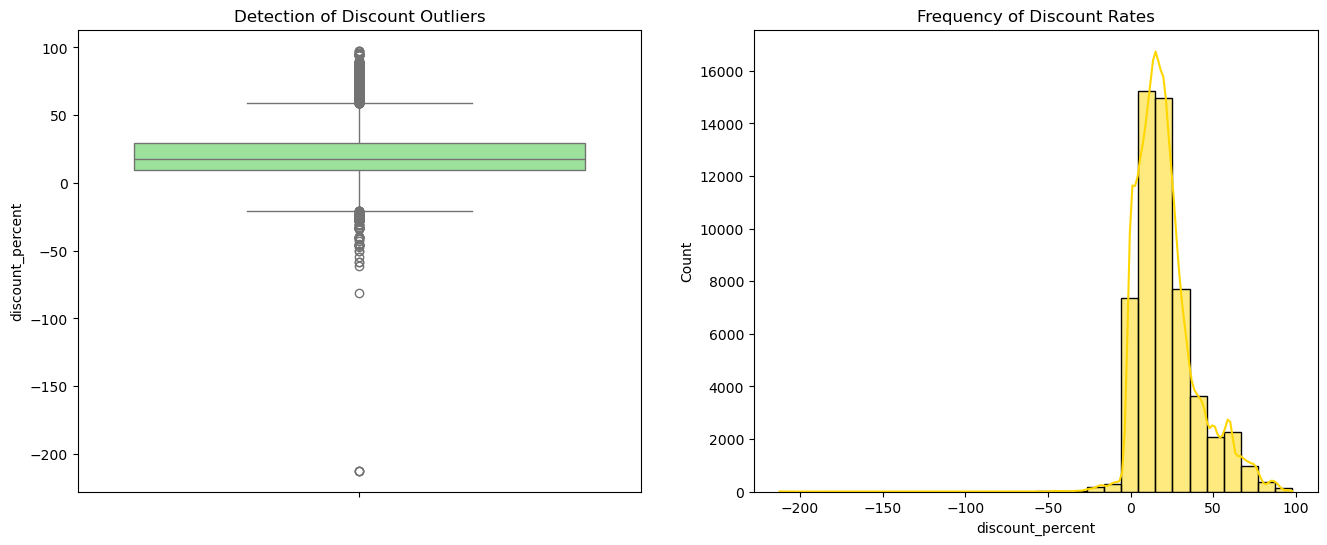

In [82]:
# Prepare the graphics area
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot to identify the "whiskers" and extreme outliers
sns.boxplot(data=merged_product_orderline_df, y='discount_percent', ax=ax[0], color='lightgreen')
ax[0].set_title('Detection of Discount Outliers')

# Histogram to see the common "logical space"
sns.histplot(data=merged_product_orderline_df, x='discount_percent', bins=30, kde=True, ax=ax[1], color='gold')
ax[1].set_title('Frequency of Discount Rates')

plt.show()

In [83]:
# Calculate quartiles
Q1 = merged_product_orderline_df['discount_percent'].quantile(0.25)
Q3 = merged_product_orderline_df['discount_percent'].quantile(0.75)
IQR = Q3 - Q1

# Define statistical limits
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Statistical Lower Limit: {lower_bound:.2f}%")
print(f"Statistical Upper Limit: {upper_bound:.2f}%")

Statistical Lower Limit: -20.41%
Statistical Upper Limit: 58.87%


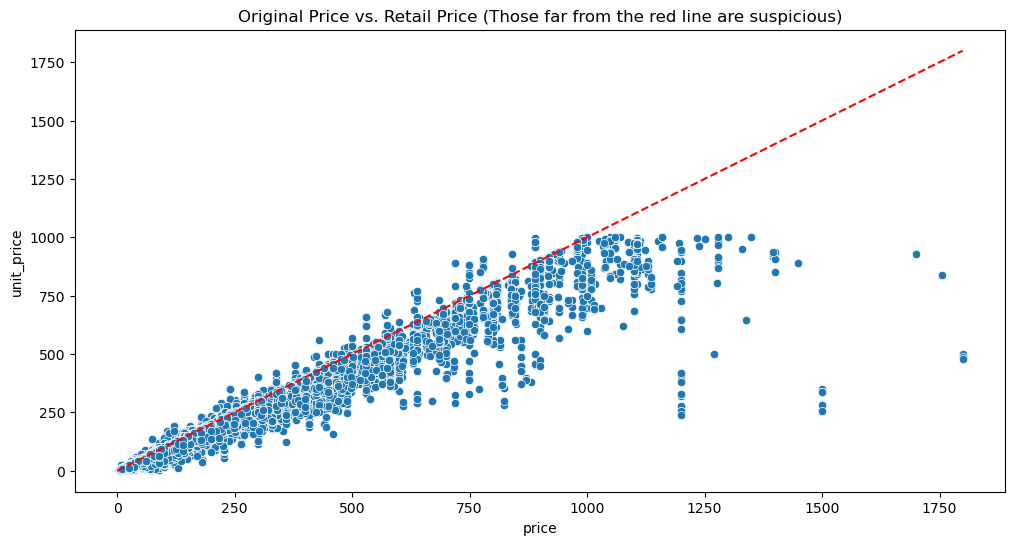

In [84]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=merged_product_orderline_df, x='price', y='unit_price')

# Reference line (unit_price = price line, non-discounted sales)
plt.plot([0, merged_product_orderline_df['price'].max()], [0, merged_product_orderline_df['price'].max()], color='red', linestyle='--')

plt.title('Original Price vs. Retail Price (Those far from the red line are suspicious)')
plt.show()

In [85]:
top_revenue_product_categories = (
    merged_product_orderline_df.groupby('product_family')['revenue']
    .sum()
    .nlargest(4)
    .index.tolist()
)


top_revenue_brands = (
    merged_product_orderline_df.groupby('category_brand')['revenue']
    .sum()
    .nlargest(4)
    .index.tolist()
)

In [86]:
top_revenue_brands 

['Apple', 'Pack', 'OWC', 'LaCie']

In [87]:
top_revenue_product_categories 

['Storage', 'iPhone, iPhone', 'iPhone', 'Enhancements']

--- Simple Statistical Summary for Your Presentation ---
                   Mean (Average)  Median (Middle)  Max (Peak)  Min (Lowest)
total_revenue           538514.73        405038.98  1554006.98      26083.86
avg_discount_rate           20.84            20.80       25.11         15.63
total_quantity            4156.73          3139.00     9973.00        248.00


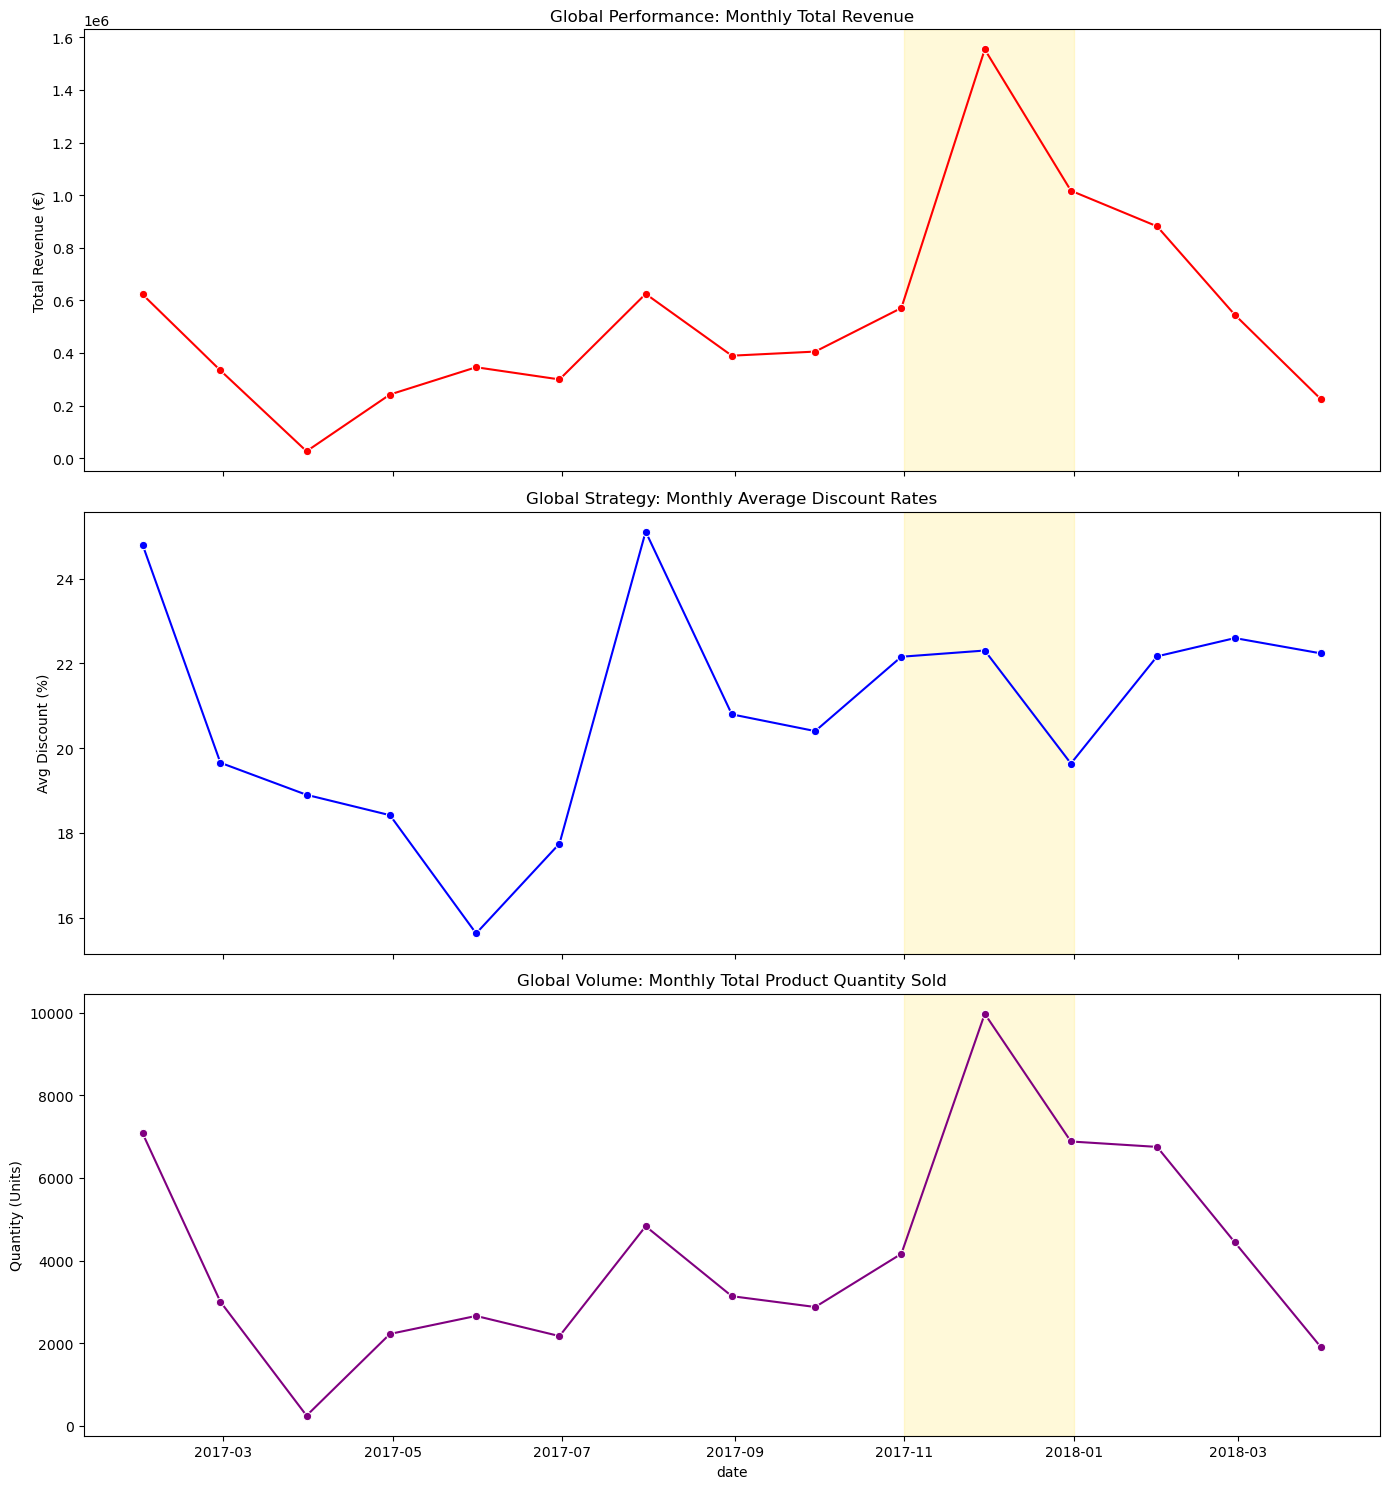

In [60]:
# Adjust the years/dates to match your special dates
special_day_start = pd.Timestamp("2017-11-01")
special_day_end = pd.Timestamp("2018-01-01")

# Global Monthly Aggregation
total_aggs = (merged_product_orderline_df
              .set_index('date')
              .resample('ME') 
              .agg(
                  total_revenue=('revenue', 'sum'),
                  avg_discount_rate=('discount_percent', 'mean'),
                  total_quantity=('product_quantity', 'sum')
              )
              .reset_index())

# Visualization 
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

# Total Revenue
sns.lineplot(data=total_aggs, x="date", y="total_revenue", ax=axes[0], color='red', marker='o')
axes[0].set_title("Global Performance: Monthly Total Revenue")
axes[0].set_ylabel("Total Revenue (€)")

# Average Discount Rate
sns.lineplot(data=total_aggs, x="date", y="avg_discount_rate", ax=axes[1], color='blue', marker='o')
axes[1].set_title("Global Strategy: Monthly Average Discount Rates")
axes[1].set_ylabel("Avg Discount (%)")

# Product Quantity
sns.lineplot(data=total_aggs, x="date", y="total_quantity", ax=axes[2], color='purple', marker='o')
axes[2].set_title("Global Volume: Monthly Total Product Quantity Sold")
axes[2].set_ylabel("Quantity (Units)")

# Statistical Aggs
stats_summary = total_aggs[['total_revenue', 'avg_discount_rate', 'total_quantity']].agg(['mean', 'median', 'max', 'min']).transpose()
stats_summary.columns = ['Mean (Average)', 'Median (Middle)', 'Max (Peak)', 'Min (Lowest)']
print("--- Simple Statistical Summary for Your Presentation ---")
print(stats_summary.round(2))

# Adding special dates
for ax in axes:
    ax.axvspan(special_day_start, special_day_end, color='gold', alpha=0.15)

plt.tight_layout()
plt.show()

In [61]:
# Adjust the years/dates to match your special dates
special_day_start = pd.Timestamp("2017-11-01")
special_day_end = pd.Timestamp("2018-01-01")

# Filtered Dataframe for top 3 Category Brand
df_top_brands = merged_product_orderline_df[merged_product_orderline_df['category_brand'].isin(top_brands)].copy()

brand_aggs = (df_top_brands
              .set_index('date')
              .groupby('category_brand')
              .resample('ME', include_groups=False) 
              .agg(
                  total_revenue=('revenue', 'sum'),
                  avg_discount_rate=('discount_percent', 'mean'),
                  total_quantity=('product_quantity', 'sum')
              )
              .reset_index())

# Visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

# Revenue Performance
sns.lineplot(data=brand_aggs, x="date", y="total_revenue", hue="category_brand", ax=axes[0], marker='o')
axes[0].set_title("1. Analysis of Monthly Total Revenue by top 3 Category Brand")
axes[0].set_ylabel("Total Revenue (€)")

# Discount Strategy
sns.lineplot(data=brand_aggs, x="date", y="avg_discount_rate", hue="category_brand", ax=axes[1], marker='o')
axes[1].set_title("2. Analysis of Monthly Average Discount Rates by top 3 Category Brand")
axes[1].set_ylabel("Avg Discount (%)")

# Quantity Sold
sns.lineplot(data=brand_aggs, x="date", y="total_quantity", hue="category_brand", ax=axes[2], marker='o')
axes[2].set_title("3. Analysis of Monthly Product Quantity by top 3 Category Brand")
axes[2].set_ylabel("Quantity Sold (Units)")

# Adding special dates
for ax in axes:
    ax.axvspan(special_day_start, special_day_end, color='gold', alpha=0.15)

plt.tight_layout()
plt.show()

NameError: name 'top_brands' is not defined

In [ ]:
# Adjust the years/dates to match your special dates
special_day_start = pd.Timestamp("2017-11-01")
special_day_end = pd.Timestamp("2018-01-01")

# Filtered Dataframe for top 3 Category Product Family
df_top_product_families = merged_product_orderline_df[merged_product_orderline_df['product_family'].isin(top_product_families)].copy()


# Monthly Aggregation for Product Families
product_family_aggs = (df_top_product_families
               .set_index('date')
               .groupby('product_family')
               .resample('ME', include_groups=False) 
               .agg(
                   total_revenue=('revenue', 'sum'),
                   avg_discount_rate=('discount_percent', 'mean'),
                   total_quantity=('product_quantity', 'sum')
               )
               .reset_index())

# Visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

# Total Revenue
sns.lineplot(data=product_family_aggs, x="date", y="total_revenue", hue="product_family", ax=axes[0], marker='o')
axes[0].set_title("1. Monthly Total Revenue Performance by Top 3 Product Family")
axes[0].set_ylabel("Total Revenue (€)")

# verage Discount Rate
sns.lineplot(data=product_family_aggs, x="date", y="avg_discount_rate", hue="product_family", ax=axes[1], marker='o')
axes[1].set_title("2. Monthly Average Discount Rates by Top 3 Product Family")
axes[1].set_ylabel("Avg Discount (%)")

# Product Quantity
sns.lineplot(data=product_family_aggs, x="date", y="total_quantity", hue="product_family", ax=axes[2], marker='o')
axes[2].set_title("3. Monthly Total Units Sold (Product Quantity) by Top 3 Product Family")
axes[2].set_ylabel("Quantity Sold (Units)")


# Adding special dates
for ax in axes:
    ax.axvspan(special_day_start, special_day_end, color='gold', alpha=0.15)
    
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

# Create a scatter plot adding a 3rd dimension by mapping 'total_quantity' to point size
sns.scatterplot(
    data=product_family_aggs, 
    x="avg_discount_rate", 
    y="total_revenue", 
    hue="product_family", 
    size="total_quantity", 
    sizes=(20, 200) # Define the range of point sizes
)

# Set the chart title and axis labels
plt.title("Discount Rate vs. Total Revenue (Annual Relationship)")
plt.xlabel("Average Discount (%)")
plt.ylabel("Total Revenue (€)")

# Add a dashed grid for easier data point alignment
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()

In [ ]:
# Firstly all columns are as Normal Period
product_family_aggs['period_type'] = 'Normal Period'

# Customize for special days
mask = (product_family_aggs['date'] >= special_day_start) & (product_family_aggs['date'] <= special_day_end)
product_family_aggs.loc[mask, 'period_type'] = 'Special Period'

# Compare average revenue and discount across product families and period types
period_comparison = product_family_aggs.groupby(['product_family', 'period_type']).agg({
    'total_revenue': 'sum',
    'avg_discount_rate': 'mean'       
}).reset_index()

# Visualization: 2 subplots
fig, axes = plt.subplots(2, 1, figsize=(7, 6))

# 1. Revenue
sns.barplot(
    data=period_comparison,
    x='product_family',
    y='total_revenue',
    hue='period_type',
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title("Impact of Special Periods on Revenue by Top 3 Product Family", fontsize=14)
axes[0].set_ylabel("Total Monthly Revenue (€)")
axes[0].set_xlabel("")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(title='Period Type')

# 2. Average Discount Rate
sns.barplot(
    data=period_comparison,
    x='product_family',
    y='avg_discount_rate',
    hue='period_type',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("Impact of Special Periods on Average Discounts by Top 3 Product Family", fontsize=14)
axes[1].set_ylabel("Average Discount (%)")
axes[1].set_xlabel("Product Family")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend(title='Period Type')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Firstly all columns are as Normal Period
brand_aggs['period_type'] = 'Normal Period'

# Customize for special days
mask = (brand_aggs['date'] >= special_day_start) & (brand_aggs['date'] <= special_day_end)
brand_aggs.loc[mask, 'period_type'] = 'Special Period'

# Compare average revenue and discount across brand and period types
period_comparison = brand_aggs.groupby(['category_brand', 'period_type']).agg({
    'total_revenue': 'sum',
    'avg_discount_rate': 'mean'       
}).reset_index()

# Visualization: 2 subplots
fig, axes = plt.subplots(2, 1, figsize=(7, 6))

# 1. Revenue
sns.barplot(
    data=period_comparison,
    x='category_brand',
    y='total_revenue',
    hue='period_type',
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title("Impact of Special Periods on Revenue by Top 3 Brand Categories", fontsize=14)
axes[0].set_ylabel("Total Monthly Revenue (€)")
axes[0].set_xlabel("")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(title='Period Type')

# 2. Average Discount Rate
sns.barplot(
    data=period_comparison,
    x='category_brand',
    y='avg_discount_rate',
    hue='period_type',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("Impact of Special Periods on Average Discounts by Top 3 Brand Categories", fontsize=14)
axes[1].set_ylabel("Average Discount (%)")
axes[1].set_xlabel("Product Family")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend(title='Period Type')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Prepare data
df_prod = merged_product_orderline_df[merged_product_orderline_df['product_family'].isin(top_revenue_product_categories)].copy()

product_category_aggs = (
    df_prod.set_index('date')
    .groupby('product_family')
    .resample('ME', include_groups=False)
    .agg(
        total_revenue=('revenue', 'sum'),
        avg_discount_rate=('discount_percent', 'mean'),
        total_quantity=('product_quantity', 'sum')
    )
    .reset_index()
)
product_category_aggs['date'] = pd.to_datetime(product_category_aggs['date'])

# Create 2 rows for Revenue and Volume
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Style Settings
sns.set_style("whitegrid")
palette = sns.color_palette("husl", len(top_revenue_product_categories))

# Revenue Plot
sns.lineplot(data=product_category_aggs, x="date", y="total_revenue", hue="product_family", ax=ax1, palette=palette)
ax1.set_title("Top 4 Product Categories: Monthly Revenue & Discount Impact", loc="left", fontsize=14, fontweight='bold')
ax1.set_ylabel("Total Revenue (€)")
ax1.get_legend().remove() 

# Sales Volume Plot
sns.lineplot(data=product_category_aggs, x="date", y="total_quantity", hue="product_family", ax=ax2, palette=palette)
ax2.set_title("Top 4 Product Categories: Monthly Sales Performance & Discount Impact", loc="left", fontsize=14, fontweight='bold')
ax2.set_ylabel("Units Sold")
ax2.get_legend().remove()

# Unified Legend at the bottom
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, 0.02), title="Product Categories", frameon=True)

# Discount Labels for Specific Dates
special_dates = ['2017-03-31', '2017-11-30', '2018-03-31']

for s_date in special_dates:
    ts = pd.Timestamp(s_date)
    data_at_date = product_category_aggs[product_category_aggs['date'] == ts]
    
    if not data_at_date.empty:
        # Add vertical dashed lines for alignment
        ax1.axvline(ts, color='gray', linestyle='--', alpha=0.3)
        ax2.axvline(ts, color='gray', linestyle='--', alpha=0.3)
        
        # Create the label text for the annotation
        label_text = f"DATE: {s_date}\n" + "-"*15 + "\n"
        for _, row in data_at_date.iterrows():
            label_text += f"{row['product_family']}: {row['avg_discount_rate']:.0f}%\n"
        
        # Place the annotation on the Revenue chart
        ax1.annotate(label_text, 
                     xy=(ts, ax1.get_ylim()[1] * 0.75), 
                     xytext=(10, 0), textcoords='offset points',
                     fontsize=8, fontweight='bold',
                     bbox=dict(boxstyle="round,pad=0.5", fc="yellow", ec="black", alpha=0.7))

# Highlight the Special Dates
for ax in [ax1, ax2]:
    ax.axvspan(pd.Timestamp("2017-11-01"), pd.Timestamp("2018-01-01"), color="gold", alpha=0.15)

# Adjust layout to make room for the legend at the bottom
plt.tight_layout(rect=[0, 0.08, 1, 1]) 

plt.savefig("my_analysis_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Prepare data 
df_brand = merged_product_orderline_df[merged_product_orderline_df['category_brand'].isin(top_revenue_brands)].copy()

brand_aggs = (
    df_brand.set_index('date')
    .groupby('category_brand')
    .resample('ME', include_groups=False)
    .agg(
        total_revenue=('revenue', 'sum'),
        avg_discount_rate=('discount_percent', 'mean'),
        total_quantity=('product_quantity', 'sum')
    )
    .reset_index()
)
brand_aggs['date'] = pd.to_datetime(brand_aggs['date'])

# Create Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Style Settings
sns.set_style("whitegrid")
palette = sns.color_palette("husl", len(top_revenue_brands))

# Revenue Plot
sns.lineplot(data=brand_aggs, x="date", y="total_revenue", hue="category_brand", ax=ax1, palette=palette)
ax1.set_title("Top 4 Brand Categories: Monthly Revenue & Discount Impact", loc="left", fontsize=14, fontweight='bold')
ax1.set_ylabel("Total Revenue (€)")
ax1.get_legend().remove() 

# Sales Volume Plot
sns.lineplot(data=brand_aggs, x="date", y="total_quantity", hue="category_brand", ax=ax2, palette=palette)
ax2.set_title("Top 4 Brand Categories: Monthly Sales Performance & Discount Impact", loc="left", fontsize=14, fontweight='bold')
ax2.set_ylabel("Units Sold")
ax2.get_legend().remove()

# Unified Legend at the Bottom
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, 0.02), title="Top Brands", frameon=True)

# Discount Labels for Specific Dates
special_dates = ['2017-03-31', '2017-11-30', '2018-03-31']

for s_date in special_dates:
    ts = pd.Timestamp(s_date)
    data_at_date = brand_aggs[brand_aggs['date'] == ts]
    
    if not data_at_date.empty:
        # Vertical dashed lines for alignment
        ax1.axvline(ts, color='gray', linestyle='--', alpha=0.3)
        ax2.axvline(ts, color='gray', linestyle='--', alpha=0.3)
        
        # Create the label text for the annotation
        label_text = f"DATE: {s_date}\n" + "-"*15 + "\n"
        for _, row in data_at_date.iterrows():
            label_text += f"{row['category_brand']}: {row['avg_discount_rate']:.0f}%\n"
        
        # Place the annotation on the Revenue chart
        ax1.annotate(label_text, 
                     xy=(ts, ax1.get_ylim()[1] * 0.75), 
                     xytext=(10, 0), textcoords='offset points',
                     fontsize=8, fontweight='bold',
                     bbox=dict(boxstyle="round,pad=0.5", fc="yellow", ec="black", alpha=0.7))

# Highlight the Special Period (e.g., Holiday Season)
for ax in [ax1, ax2]:
    ax.axvspan(pd.Timestamp("2017-11-01"), pd.Timestamp("2018-01-01"), color="gold", alpha=0.15)

# Adjust layout to make room for the legend at the bottom
plt.tight_layout(rect=[0, 0.08, 1, 1]) 

plt.savefig("brand_performance_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 1. DATA PREPARATION 
product_category_aggs = (
    df_prod.set_index('date')
    .groupby('product_family')
    .resample('ME', include_groups=False) 
    .agg(
        total_revenue=('revenue', 'sum'),
        avg_discount_rate=('discount_percent', 'mean'),
        total_quantity=('product_quantity', 'sum')
    )
    .reset_index()
)

# 2. PLOT SETTINGS
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
sns.set_style("white")
palette = sns.color_palette("husl", len(top_revenue_product_categories))

# --- PLOT 1: REVENUE ---
sns.lineplot(data=product_category_aggs, x="date", y="total_revenue", hue="product_family", 
             ax=ax1, palette=palette, linewidth=2.5)
ax1.set_ylabel("Total Revenue (€)", fontweight='bold')
ax1.set_title("Top Categories: Revenue vs. Discount Impact", loc="left", fontsize=14, fontweight='bold')

# Discount Axis (Right)
ax1_twin = ax1.twinx()
avg_disc = product_category_aggs.groupby('date')['avg_discount_rate'].mean()
ax1_twin.plot(avg_disc.index, avg_disc.values, color='black', linestyle='--', alpha=0.5, label='Avg Discount % (All)')
ax1_twin.set_ylabel("Avg Discount (%)", color='black', alpha=0.6)

# --- PLOT 2: SALES VOLUME ---
sns.lineplot(data=product_category_aggs, x="date", y="total_quantity", hue="product_family", 
             ax=ax2, palette=palette, linewidth=2.5, legend=False)
ax2.set_ylabel("Units Sold", fontweight='bold')
ax2.set_title("Top Categories: Sales Volume vs. Discount Impact", loc="left", fontsize=14, fontweight='bold')

# Discount Axis (Right)
ax2_twin = ax2.twinx()
ax2_twin.plot(avg_disc.index, avg_disc.values, color='red', linestyle='--', alpha=0.4, label='Avg Discount %')
ax2_twin.set_ylabel("Avg Discount (%)", color='red', alpha=0.6)

# Highlight Period
for ax in [ax1, ax2]:
    ax.axvspan(pd.Timestamp("2017-11-01"), pd.Timestamp("2018-01-01"), color="gray", alpha=0.1)
    ax.grid(True, alpha=0.2)

# 4. LEGEND 

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax1_twin.get_legend_handles_labels()


if ax1.get_legend(): ax1.get_legend().remove()
fig.legend(h1 + h2, l1 + l2, loc='lower center', ncol=len(l1)+len(l2), 
           bbox_to_anchor=(0.5, -0.02), frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.show()


In [ ]:
# 1. DATA PREPARATION 
product_category_aggs = (
    df_prod.set_index('date')
    .groupby('product_family')
    .resample('ME', include_groups=False) 
    .agg(
        total_revenue=('revenue', 'sum'),
        avg_discount_rate=('discount_percent', 'mean'),
        total_quantity=('product_quantity', 'sum')
    )
    .reset_index()
)

# 2. PLOT SETTINGS
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
sns.set_style("white")
palette = sns.color_palette("husl", len(top_revenue_product_categories))

# --- PLOT 1: REVENUE ---
sns.lineplot(data=product_category_aggs, x="date", y="total_revenue", hue="product_family", 
             ax=ax1, palette=palette, linewidth=2.5)
ax1.set_ylabel("Total Revenue (€)", fontweight='bold')
ax1.set_title("Top Categories: Revenue vs. Discount Impact", loc="left", fontsize=14, fontweight='bold')

# Discount Axis (Right)
ax1_twin = ax1.twinx()
avg_disc = product_category_aggs.groupby('date')['avg_discount_rate'].mean()
ax1_twin.plot(avg_disc.index, avg_disc.values, color='black', linestyle='--', alpha=0.5, label='Avg Discount % (All)')
ax1_twin.set_ylabel("Avg Discount (%)", color='black', alpha=0.6)

# --- PLOT 2: SALES VOLUME ---
sns.lineplot(data=product_category_aggs, x="date", y="total_quantity", hue="product_family", 
             ax=ax2, palette=palette, linewidth=2.5, legend=False)
ax2.set_ylabel("Units Sold", fontweight='bold')
ax2.set_title("Top Categories: Sales Volume vs. Discount Impact", loc="left", fontsize=14, fontweight='bold')

# Discount Axis (Right)
ax2_twin = ax2.twinx()
ax2_twin.plot(avg_disc.index, avg_disc.values, color='red', linestyle='--', alpha=0.4, label='Avg Discount %')
ax2_twin.set_ylabel("Avg Discount (%)", color='red', alpha=0.6)

# Highlight Period
for ax in [ax1, ax2]:
    ax.axvspan(pd.Timestamp("2017-11-01"), pd.Timestamp("2018-01-01"), color="gray", alpha=0.1)
    ax.grid(True, alpha=0.2)

# 4. LEGEND 

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax1_twin.get_legend_handles_labels()


if ax1.get_legend(): ax1.get_legend().remove()
fig.legend(h1 + h2, l1 + l2, loc='lower center', ncol=len(l1)+len(l2), 
           bbox_to_anchor=(0.5, -0.02), frameon=True)

plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.show()
